# 02 - Correlation Analysis in Multivariate Financial Time Series

## Description

This notebook explores the relationships between multiple financial time series, including cryptocurrency and traditional market indicators.

The analysis focuses on:

- Linear correlations (Pearson)
- Rank-based correlations (Spearman)
- Lagged relationships
- Rolling (dynamic) correlations
- Granger Causality

The goal is to identify dependencies and temporal interactions between variables, which will inform feature selection and model design in subsequent deep learning experiments.

# 1. Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 2. Load processed data

In [36]:
df = pd.read_csv("../data/generated/processed_full.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,btc_open,btc_close,eth_open,eth_close,bnb_open,bnb_close,xrp_open,xrp_close,sp500,...,eth_return,bnb_return,xrp_return,sp500_return,dow_return,gold_return,btc_intraday,eth_intraday,bnb_intraday,xrp_intraday
0,2017-07-27,2538.709961,2671.780029,204.856003,204.317993,0.105108,0.107737,0.175210,0.173457,2475.42,...,0.001790,0.024720,-0.002100,-0.000973,0.003940,-0.001919,0.052416,-0.002626,0.025012,-0.010005
1,2017-07-28,2679.729980,2809.010010,204.324997,193.123001,0.107632,0.104067,0.173211,0.165937,2472.10,...,-0.054792,-0.034064,-0.043354,-0.001341,0.001549,0.008336,0.048244,-0.054824,-0.033122,-0.041995
2,2017-07-31,2763.239990,2875.340088,197.404999,203.871002,0.106828,0.104250,0.165050,0.167386,2470.30,...,0.055654,0.001758,0.008732,-0.000728,0.002786,0.000363,0.040568,0.032755,-0.024132,0.014153
3,2017-08-01,2871.300049,2718.260010,204.688004,226.768997,0.104595,0.099867,0.168024,0.177053,2476.35,...,0.112316,-0.042045,0.057753,0.002449,0.003326,-0.000355,-0.053300,0.107876,-0.045205,0.053736
4,2017-08-02,2727.129883,2710.669922,227.005997,219.951996,0.099721,0.100452,0.177531,0.173113,2477.57,...,-0.030061,0.005860,-0.022253,0.000493,0.002382,-0.002159,-0.006036,-0.031074,0.007328,-0.024886


# 3. Select returns

In [37]:
returns_cols = [
    "btc_return",
    "eth_return",
    "bnb_return",
    "xrp_return",
    "sp500_return",
    "dow_return",
    "gold_return"
]

df_returns = df[returns_cols].copy()

# 4. Pearson Correlation

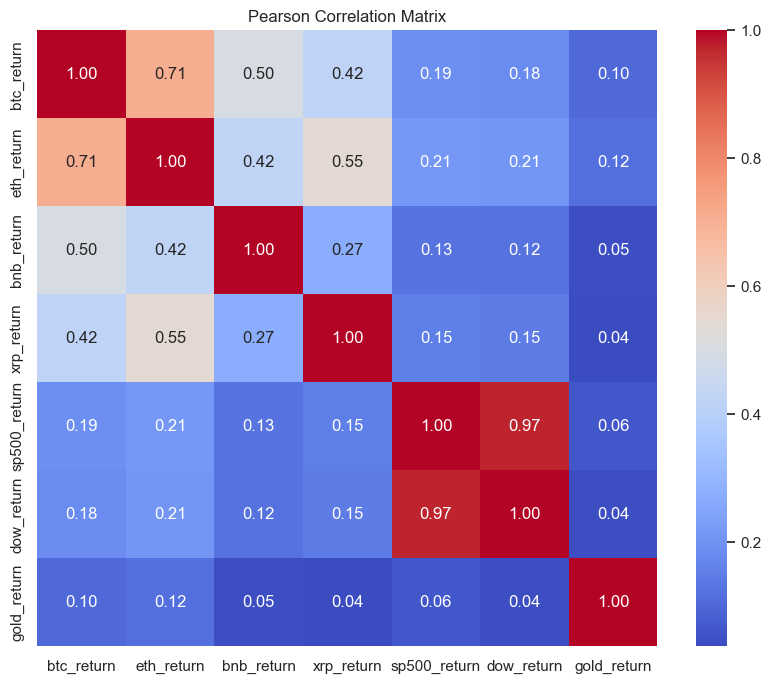

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(df_returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Matrix")
plt.show()

# 5. Spearman Correlation

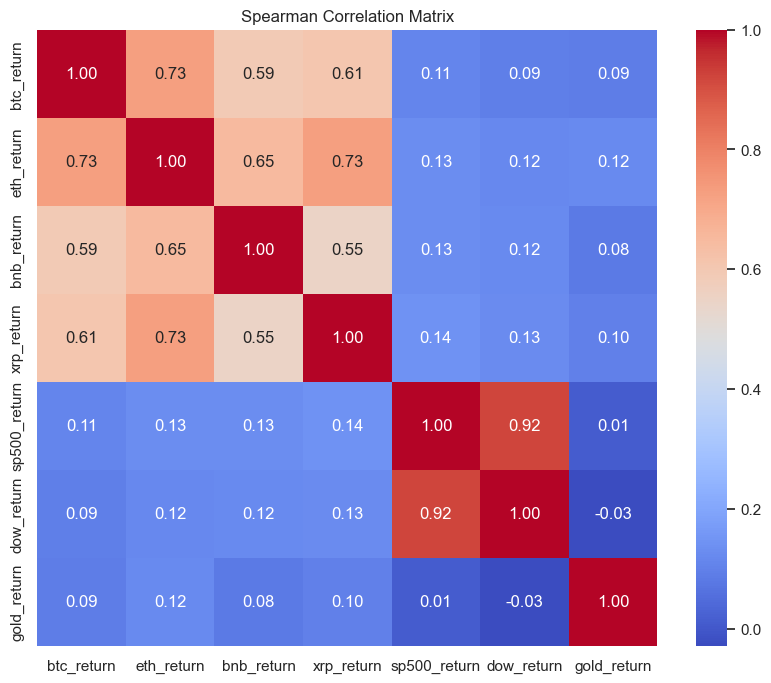

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(df_returns.corr(method="spearman"), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation Matrix")
plt.show()

# 6. Lagged Correlation

In [40]:
def lag_correlation(df, target, feature, max_lag=30):
    lags = range(1, max_lag + 1)
    correlations = []

    for lag in lags:
        corr = df[target].corr(df[feature].shift(lag))
        correlations.append(corr)

    return pd.DataFrame({
        "lag": lags,
        "correlation": correlations
    })

# BTC vs SP500 (Example)

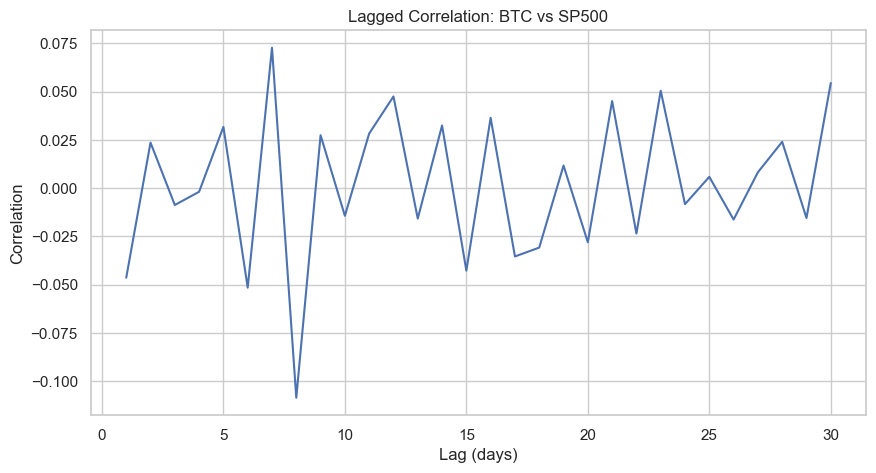

In [41]:
lag_df = lag_correlation(df, "btc_return", "sp500_return", max_lag=30)

plt.figure(figsize=(10,5))
plt.plot(lag_df["lag"], lag_df["correlation"])
plt.title("Lagged Correlation: BTC vs SP500")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.show()

## Lag Analysis Interpretation

Lagged correlations suggest weak predictive relationships from traditional markets to Bitcoin, as correlations remain low across different lag values.

In contrast, cryptocurrency variables tend to show stronger short-term dependencies, indicating faster information propagation within the crypto market.

# All features

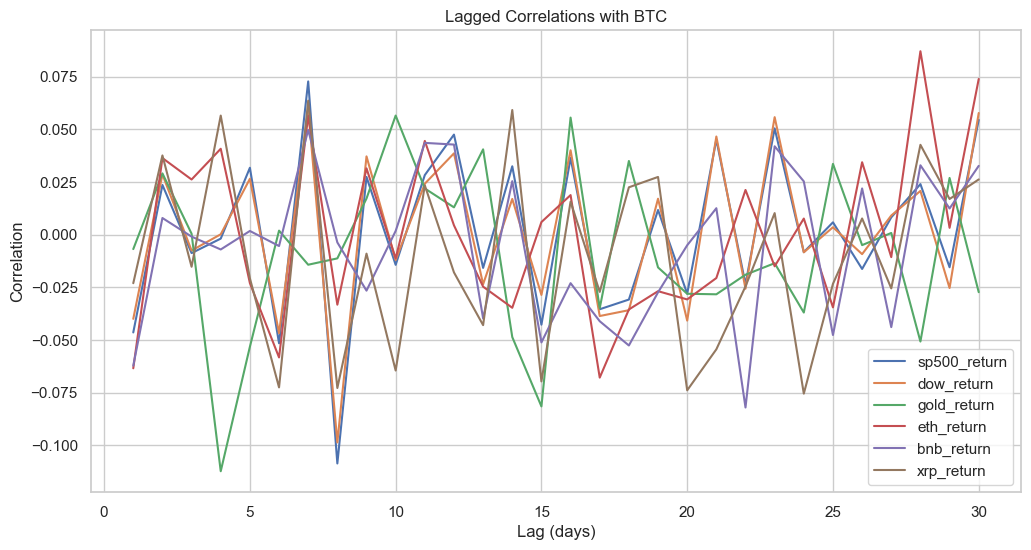

In [42]:
features = [
    "sp500_return",
    "dow_return",
    "gold_return",
    "eth_return",
    "bnb_return",
    "xrp_return"
]

plt.figure(figsize=(12,6))

for feature in features:
    lag_df = lag_correlation(df, "btc_return", feature, max_lag=30)
    plt.plot(lag_df["lag"], lag_df["correlation"], label=feature)

plt.legend()
plt.title("Lagged Correlations with BTC")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.show()

# 7. Rolling Correlation

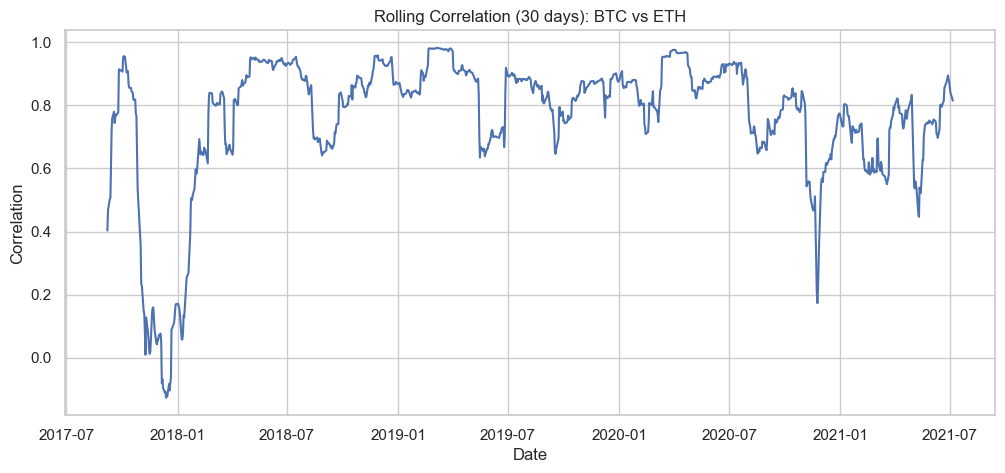

In [43]:
window = 30

rolling_corr = df["btc_return"].rolling(window).corr(df["eth_return"])

plt.figure(figsize=(12,5))
plt.plot(df["date"], rolling_corr)
plt.title("Rolling Correlation (30 days): BTC vs ETH")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.show()

# multiple comparations

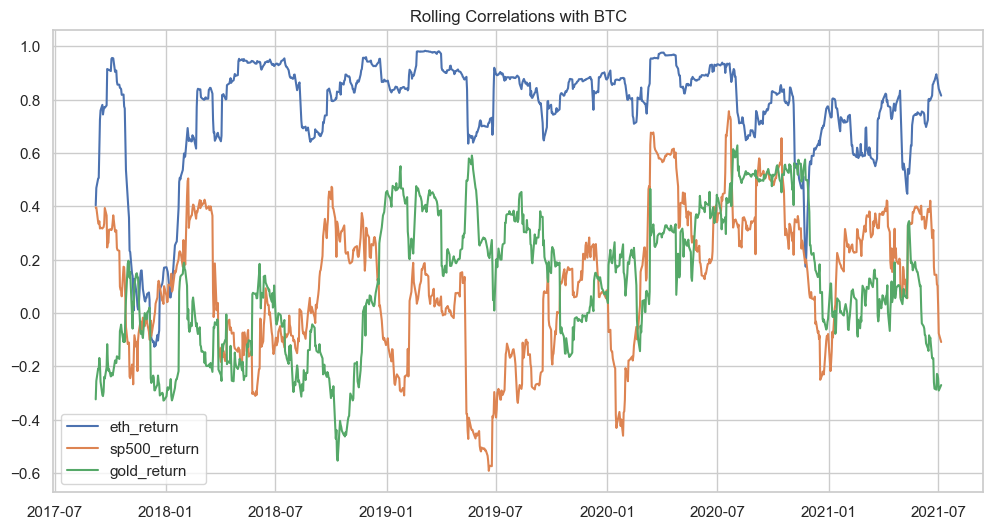

In [44]:
plt.figure(figsize=(12,6))

for feature in ["eth_return", "sp500_return", "gold_return"]:
    rolling_corr = df["btc_return"].rolling(30).corr(df[feature])
    plt.plot(df["date"], rolling_corr, label=feature)

plt.legend()
plt.title("Rolling Correlations with BTC")
plt.show()

# 9. Granger Causality

In [45]:
from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(
    df[["btc_return", "eth_return"]],
    maxlag=5
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.0816  , p=0.0436  , df_denom=988, df_num=1
ssr based chi2 test:   chi2=4.0940  , p=0.0430  , df=1
likelihood ratio test: chi2=4.0856  , p=0.0433  , df=1
parameter F test:         F=4.0816  , p=0.0436  , df_denom=988, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0921  , p=0.1240  , df_denom=985, df_num=2
ssr based chi2 test:   chi2=4.2054  , p=0.1221  , df=2
likelihood ratio test: chi2=4.1965  , p=0.1227  , df=2
parameter F test:         F=2.0921  , p=0.1240  , df_denom=985, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.8162  , p=0.1425  , df_denom=982, df_num=3
ssr based chi2 test:   chi2=5.4874  , p=0.1394  , df=3
likelihood ratio test: chi2=5.4722  , p=0.1403  , df=3
parameter F test:         F=1.8162  , p=0.1425  , df_denom=982, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.7862  , p=0.1294  

{np.int64(1): ({'ssr_ftest': (np.float64(4.081595724723589),
    np.float64(0.04362213780497169),
    np.float64(988.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(4.093989234009186),
    np.float64(0.04303595479300067),
    np.int64(1)),
   'lrtest': (np.float64(4.085555969930283),
    np.float64(0.043251220021946826),
    np.int64(1)),
   'params_ftest': (np.float64(4.081595724723625),
    np.float64(0.04362213780497169),
    np.float64(988.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.0920845947934814),
    np.float64(0.12397768758347547),
    np.float64(985.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(4.205408627097556),
    np.float64(0.1221257150525674),
    np.int64(2)),
   'lrtest': (np.float64(4.196501790307593),
    np.float64(0.1226708048139741),
    np.int64(2)),
   'params_ftest': (np.float64(2.0920845947934805),
    np.float64(0.12397768758347547),
    np.float64(985.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
     

## Granger Causality Interpretation

The Granger causality test suggests that Ethereum returns may have a statistically significant predictive relationship with Bitcoin returns at lag 1 (p < 0.05).

However, this effect is not consistent across higher lags, indicating that the relationship is short-term and relatively weak.

## Correlation by Feature Groups

# Crypto-only

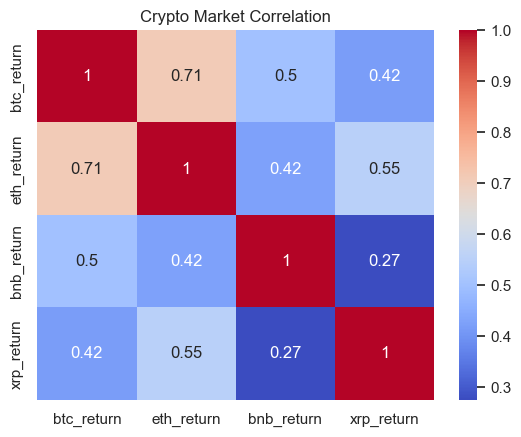

In [46]:
crypto_cols = [
    "btc_return",
    "eth_return",
    "bnb_return",
    "xrp_return"
]

sns.heatmap(df[crypto_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Crypto Market Correlation")
plt.show()

# Traditional-only

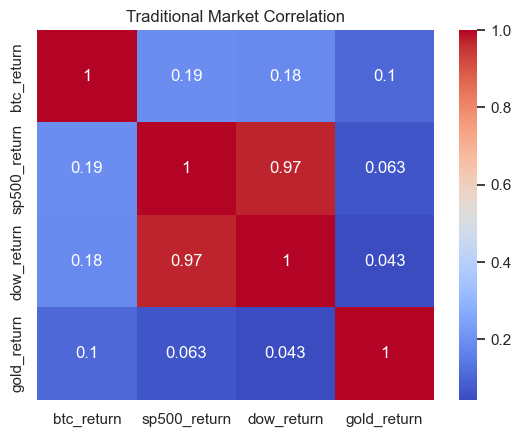

In [47]:
trad_cols = [
    "btc_return",
    "sp500_return",
    "dow_return",
    "gold_return"
]

sns.heatmap(df[trad_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Traditional Market Correlation")
plt.show()

## Key Observations

- Traditional financial indicators such as S&P 500 and Dow Jones exhibit very high correlation, indicating redundancy in information.
- Cryptocurrency variables show stronger correlations with Bitcoin compared to traditional financial indicators.
- Lagged correlations suggest short-term dependencies, particularly within the crypto market.
- Rolling correlations indicate that relationships between assets are not stable over time, highlighting dynamic market behavior.

## Final Conclusions

The analysis reveals that Bitcoin is more strongly influenced by the cryptocurrency market than by traditional financial indicators.

While traditional markets such as the S&P 500 and Dow Jones exhibit high internal correlation, their relationship with Bitcoin remains weak and inconsistent across time and lag structures.

In contrast, cryptocurrency assets show stronger and more immediate relationships with Bitcoin, particularly in short-term dynamics, suggesting faster information propagation within the crypto ecosystem.

Rolling correlations further confirm that these relationships are not stable over time, indicating that financial dependencies are dynamic and context-dependent.

Overall, these findings support the use of multivariate models that incorporate cryptocurrency features, as they are likely to provide more predictive power than models based solely on traditional financial variables.